In [1]:
import hcipy as hc
import numpy as np
import matplotlib.pyplot as plt

In [2]:
# Define pupil grid
ndim = 65
diameter = 10
pupil_grid = hc.make_pupil_grid(ndim, diameter)
ref_wavelength = 1.55e-6

# Define focal grid
focal_plane_resolution = 0.5e-6  # 0.5 micron per pixel
focal_length = diameter * 5 # focal ratio of 5
focal_grid = hc.make_pupil_grid(ndim, focal_plane_resolution * ndim)

# Define aperture and wavefront
aperture = hc.make_circular_aperture(diameter)(pupil_grid)
wf = hc.Wavefront(aperture, ref_wavelength)

# Define propagator
prop = hc.FraunhoferPropagator(pupil_grid, focal_grid, focal_length)

In [110]:
from PLsim.otf import OTF
from PLsim.scene import Scene, SceneProjector
from PLsim.system.device import Device

# Define PL multimode entrance parameters (changing this would change the number of guided modes)
ncore = 1.444
nclad = 1.444 - 5.5e-3
rcore = 6e-6 # meters

otf = OTF.from_fiber_params(ncore, nclad, rcore, ref_wavelength,
                            focal_grid, pupil_grid, focal_length,
                            aperture, optimize_focal_length = False)

otf.compute()

from PLsim.system.lantern import generate_unitary_matrix

nwav = 21

base_matrix = generate_unitary_matrix(3, seed=1235467)

chromatic_vector = np.array([0, 1, 1])
dphi = 0.5

def evolve_matrix(base_matrix, chromatic_vector, nwav, dphi):

    chromatic_matrix = np.repeat(chromatic_vector, len(base_matrix)).reshape((np.shape(base_matrix))).T
    out_matrix = []
    for iw, w in enumerate(range(nwav)):
        out_matrix.append(base_matrix * np.exp(1j*chromatic_matrix*dphi * iw))
    return np.array(out_matrix)


matrix  = evolve_matrix(base_matrix, chromatic_vector, nwav, dphi)

# Define the device
device = Device(matrix)

# Define the scene
scene = Scene(pupil_grid, ref_wavelength)
scene_projector = SceneProjector(otf, scene)

# This takes some time and memory!! 
fov = 50e-3/206265
ngrid = 32
out_grid = scene_projector.compute_point_grid(fov, ngrid)

Supported modes:  ['LP01', 'LP11a', 'LP11b']
Number of modes:  3
Device initialized with:
  Lantern matrices: (21, 3, 3)
  PIC matrices: None
  Wavelengths: 21


In [111]:
np.shape(out_grid)

(3, 3, 32, 32)

In [113]:
couplingmap = device.calculate_outputs(out_grid)

In [114]:
np.shape(couplingmap)

(21, 3, 32, 32)

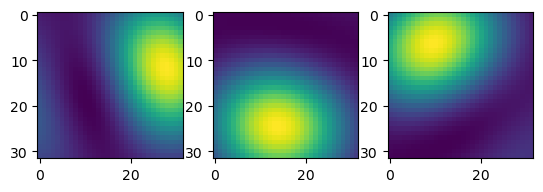

In [115]:
from IPython.display import HTML
from matplotlib.animation import FuncAnimation

fig, axs = plt.subplots(ncols=3)

def animate(wavind):

    for ax in axs: ax.clear()

    for fibind in range(3):
        axs[fibind].imshow(couplingmap[wavind, fibind])
    

anim = FuncAnimation(fig, animate, frames=nwav)
HTML(anim.to_jshtml())

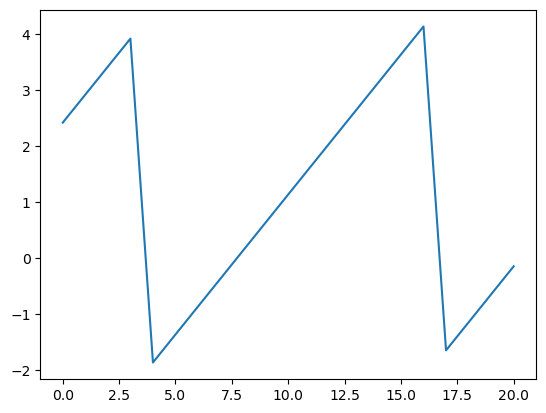

In [103]:
plt.plot(np.angle(matrix[:,0,1]) - np.angle(matrix[:,0,0]))

In [107]:
images = np.load('../disk_images.npy')
vgrid = np.linspace(-300, 300, nwav) # km/s, used for simulation of the images

# because the image is 64x64, I'll bin this into the correct grid size, 32x32
images_binned = images.reshape((nwav, ngrid, 2, ngrid, 2)).sum(axis=(2,4))

# image = np.zeros((32,32))
# image[16,16] = 1
# images = [image for i in range(21)]
# images = np.array(images)
# images_binned = images

In [108]:
disk_outs = device.calculate_outputs(scene_projector.compute_scene_from_image(images_binned))

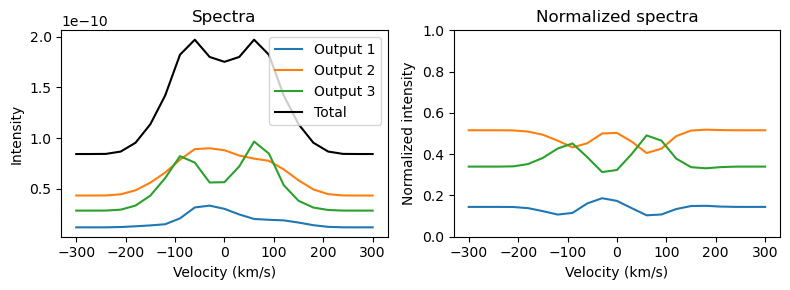

In [109]:
fig, axs = plt.subplots(ncols=2, figsize=(8,3))
for i in range(3):
    axs[0].plot(vgrid, disk_outs[:,i], label=f'Output {i+1}')
    axs[1].plot(vgrid, disk_outs[:,i]/np.sum(disk_outs,axis=1))

axs[0].plot(vgrid, np.sum(disk_outs, axis=1), label='Total', color='k')
axs[0].set_title('Spectra')
axs[1].set_title('Normalized spectra')
axs[0].set_xlabel('Velocity (km/s)')
axs[1].set_xlabel('Velocity (km/s)')
axs[0].set_ylabel('Intensity')
axs[1].set_ylabel('Normalized intensity')
axs[0].legend()
axs[1].set_ylim([0, 1])
fig.tight_layout()
plt.show()

In [8]:
np.shape(matrix)

(21, 3, 3)

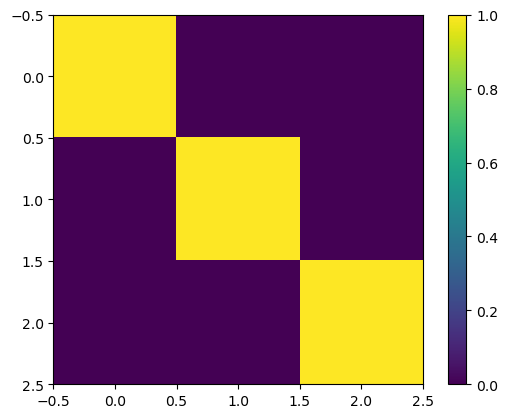

In [58]:
plt.imshow(np.abs(matrix[10] @ np.conj(matrix[10]).T))
plt.colorbar()

In [18]:
p = np.exp(1j * 0.1)
chromatic_matrix = np.repeat([1, p, p], 3).reshape((3,3)).T

In [19]:
np.shape(chromatic_matrix)

(3, 3)

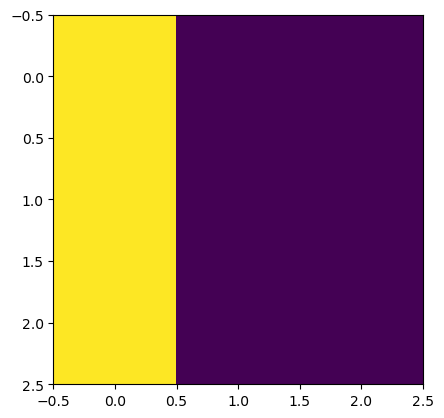

In [20]:
plt.imshow(np.abs(chromatic_matrix))

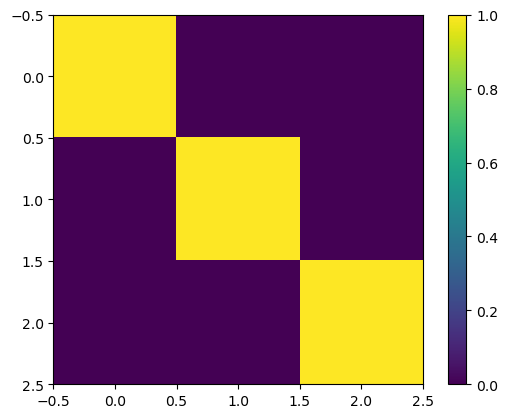

In [21]:
plt.imshow(np.abs((matrix[0] * chromatic_matrix) @ np.conj((matrix[0] * chromatic_matrix)).T))
plt.colorbar()